<a href="https://colab.research.google.com/github/Chetna2002/student-performance-analysis/blob/main/Students_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Configure chart appearance
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv("StudentsPerformance.csv")

# 1. Inspect structure
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())

# Clean column headers (lowercase, no spaces)
df.columns = [c.lower().replace(" ", "_").replace("/", "_") for c in df.columns]

# Create aggregate score features
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["average_score"] = df["total_score"] / 3

Shape: (1000, 8)

Data Types:
 gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Missing Values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Summary Statistics:
        math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.00000

/tmp/ipykernel_840/3279858974.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="parental_level_of_education", y="average_score", order=order, palette="Blues")


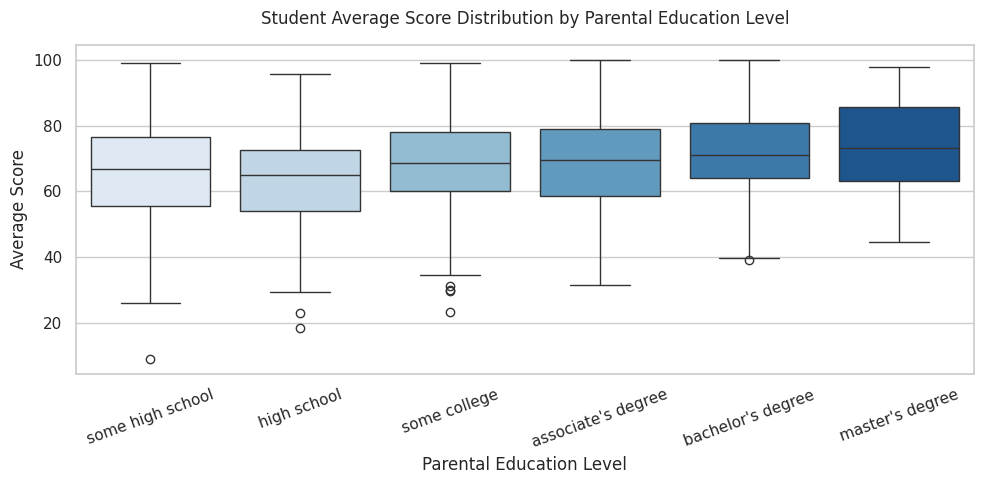

In [19]:
order = [
    "some high school", "high school", "some college",
    "associate's degree", "bachelor's degree", "master's degree"
]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="parental_level_of_education", y="average_score", order=order, palette="Blues")
plt.title("Student Average Score Distribution by Parental Education Level", pad=15)
plt.xlabel("Parental Education Level")
plt.ylabel("Average Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [22]:
prep_perf = df.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score", "average_score"]].mean().reset_index()

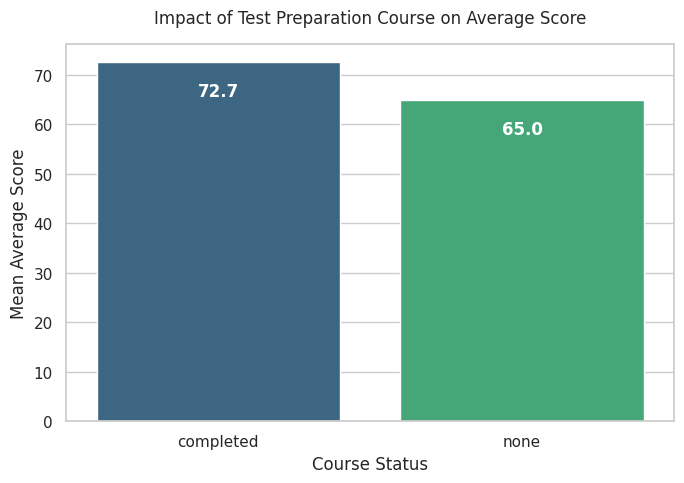

In [21]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=prep_perf,
    x="test_preparation_course",
    y="average_score",
    hue="test_preparation_course",
    palette="viridis",
    legend=False
)
plt.title("Impact of Test Preparation Course on Average Score", pad=15)
plt.xlabel("Course Status")
plt.ylabel("Mean Average Score")
for idx, row in prep_perf.iterrows():
    plt.text(idx, row["average_score"] - 7, f"{row['average_score']:.1f}", ha="center", color="white", weight="bold")
plt.tight_layout()
plt.show()

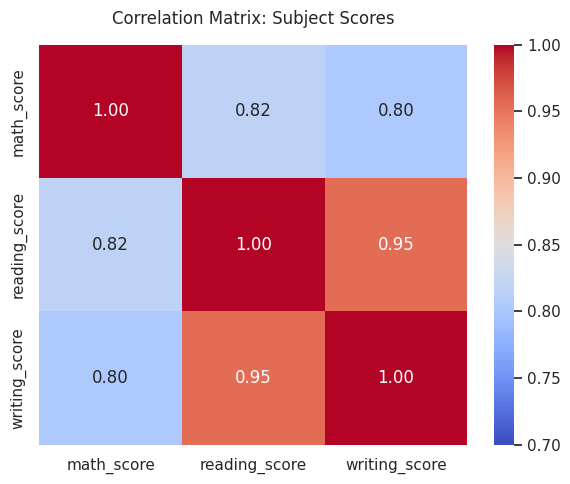

In [ ]:
corr = df[["math_score", "reading_score", "writing_score"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=0.7, vmax=1.0)
plt.title("Correlation Matrix: Subject Scores", pad=15)
plt.tight_layout()
plt.show()

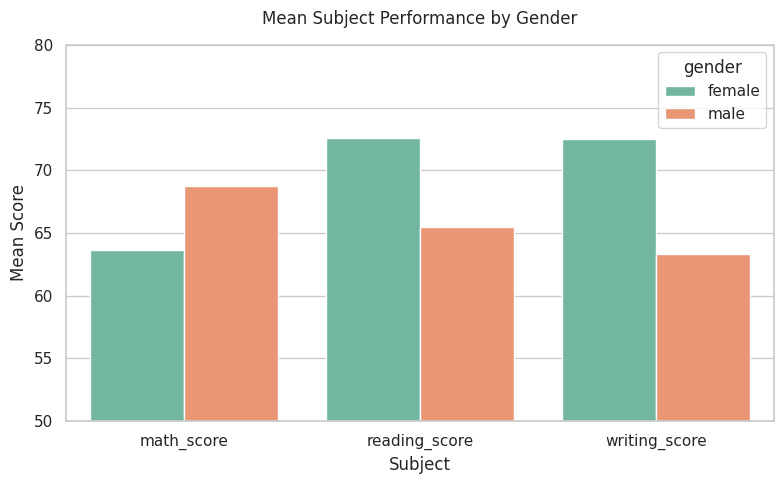

In [ ]:
gender_perf = df.groupby("gender")[["math_score", "reading_score", "writing_score"]].mean().reset_index()
gender_melted = gender_perf.melt(id_vars="gender", var_name="subject", value_name="mean_score")

plt.figure(figsize=(8, 5))
sns.barplot(data=gender_melted, x="subject", y="mean_score", hue="gender", palette="Set2")
plt.title("Mean Subject Performance by Gender", pad=15)
plt.xlabel("Subject")
plt.ylabel("Mean Score")
plt.ylim(50, 80)
plt.tight_layout()
plt.show()

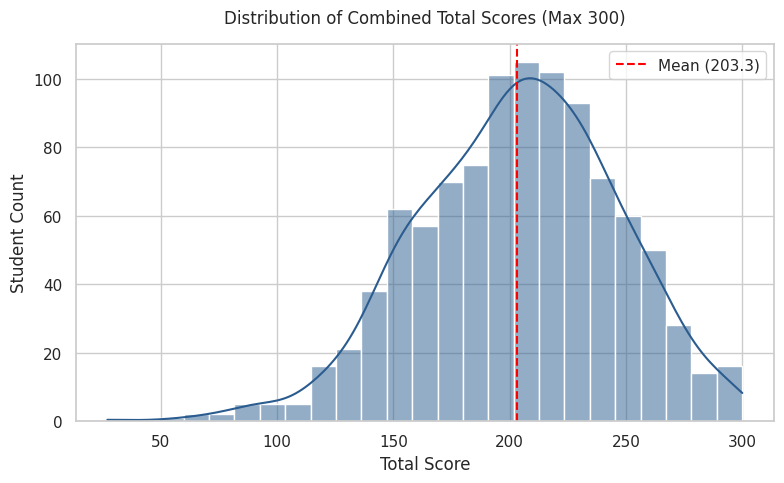

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["total_score"], kde=True, bins=25, color="#2b5c8f")
plt.axvline(df["total_score"].mean(), color="red", linestyle="--", label=f'Mean ({df["total_score"].mean():.1f})')
plt.title("Distribution of Combined Total Scores (Max 300)", pad=15)
plt.xlabel("Total Score")
plt.ylabel("Student Count")
plt.legend()
plt.tight_layout()
plt.show()

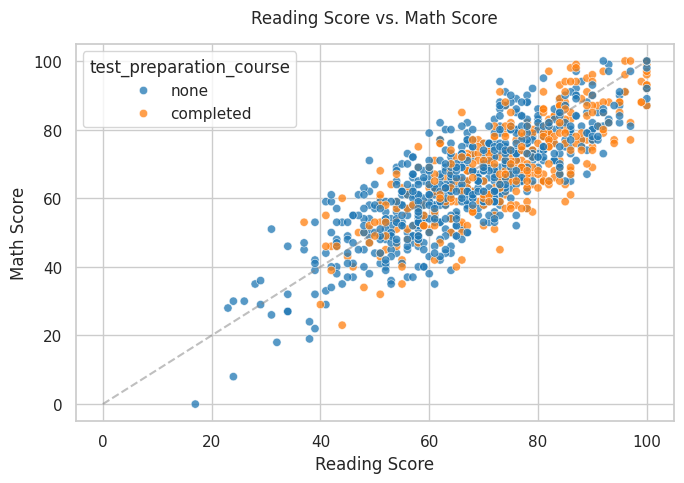

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="reading_score", y="math_score", hue="test_preparation_course", alpha=0.75, palette="tab10")
plt.title("Reading Score vs. Math Score", pad=15)
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.plot([0, 100], [0, 100], "--", color="grey", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Define At-Risk criteria: scoring strictly below 50 in ANY subject
df['is_at_risk'] = (df['math_score'] < 50) | (df['reading_score'] < 50) | (df['writing_score'] < 50)

total_students = len(df)
total_at_risk = df['is_at_risk'].sum()
at_risk_pct = (total_at_risk / total_students) * 100

print(f"Total Cohort: {total_students}")
print(f"At-Risk Students: {total_at_risk} ({at_risk_pct:.1f}%)")

# 2. Function to produce risk rates across key categorical factors
def build_risk_table(column_name):
    summary = df.groupby(column_name)['is_at_risk'].agg(
        total_students='count',
        at_risk_count='sum'
    )
    summary['at_risk_pct'] = (summary['at_risk_count'] / summary['total_students']) * 100
    return summary.sort_values(by='at_risk_pct', ascending=False)

print("\n--- Risk by Lunch Type ---")
print(build_risk_table('lunch'))

print("\n--- Risk by Test Preparation ---")
print(build_risk_table('test_preparation_course'))

print("\n--- Risk by Parental Education ---")
print(build_risk_table('parental_level_of_education'))

Total Cohort: 1000
At-Risk Students: 188 (18.8%)

--- Risk by Lunch Type ---
              total_students  at_risk_count  at_risk_pct
lunch                                                   
free/reduced             355            111    31.267606
standard                 645             77    11.937984

--- Risk by Test Preparation ---
                         total_students  at_risk_count  at_risk_pct
test_preparation_course                                            
none                                642            152    23.676012
completed                           358             36    10.055866

--- Risk by Parental Education ---
                             total_students  at_risk_count  at_risk_pct
parental_level_of_education                                            
some high school                        179             46    25.698324
high school                             196             49    25.000000
some college                            226             38    16.